# Luxury Watch Price Analysis and Prediction

## Introduction
This notebook analyzes a dataset of luxury watches and builds a predictive model for their prices. We'll explore various features of the watches and their relationship with price, as well as create a Random Forest model to predict watch prices.

In [1]:
# Importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
# Setting plot style for better visualization
plt.style.use('seaborn')

/tmp/ipykernel_16/3562968487.py:2: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn')


## Data Exploration

### Loading and Preprocessing the Data
We start by loading the dataset and performing some initial preprocessing steps.

In [3]:
# Reading the dataset
df = pd.read_csv('/kaggle/input/luxury-watches-price-dataset/Luxury watch.csv')

In [4]:
# Displaying the first few rows of the dataset
print(df.head())

       Brand       Model    Case Material   Strap Material Movement Type  \
0      Rolex  Submariner  Stainless Steel  Stainless Steel     Automatic   
1      Omega   Seamaster         Titanium           Rubber     Automatic   
2  Tag Heuer     Carrera  Stainless Steel          Leather     Automatic   
3  Breitling   Navitimer  Stainless Steel  Stainless Steel     Automatic   
4    Cartier   Tank Solo  Stainless Steel          Leather        Quartz   

  Water Resistance  Case Diameter (mm)  Case Thickness (mm)  Band Width (mm)  \
0       300 meters                40.0                13.00             20.0   
1       600 meters                43.5                14.47             21.0   
2       100 meters                41.0                13.00             20.0   
3        30 meters                43.0                14.25             22.0   
4        30 meters                31.0                 6.05             20.0   

  Dial Color Crystal Material Complications Power Reserve Pric

In [5]:
# Checking for missing values
print(df.isnull().sum())

Brand                    0
Model                    0
Case Material            0
Strap Material           0
Movement Type            0
Water Resistance         0
Case Diameter (mm)       0
Case Thickness (mm)      0
Band Width (mm)          0
Dial Color               0
Crystal Material         0
Complications          122
Power Reserve           14
Price (USD)              1
dtype: int64


In [6]:
# Data preprocessing
df['price'] = df['Price (USD)'].str.replace('$', '').str.replace(',', '').astype(float)

In [7]:
# Displaying basic statistics of the dataset
print(df.describe())

       Case Diameter (mm)  Case Thickness (mm)  Band Width (mm)         price
count          507.000000           507.000000       507.000000    506.000000
mean            41.046154            11.588343        21.105523  12082.964427
std              2.535339             2.491481         1.658375  10419.816968
min             27.500000             5.000000        15.000000    495.000000
25%             40.000000             9.800000        20.000000   5500.000000
50%             41.000000            12.000000        20.000000   8350.000000
75%             42.000000            13.300000        22.000000  16450.000000
max             46.500000            17.500000        28.000000  70000.000000


### Visualizing Price Distribution
Let's examine the distribution of watch prices in our dataset.

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


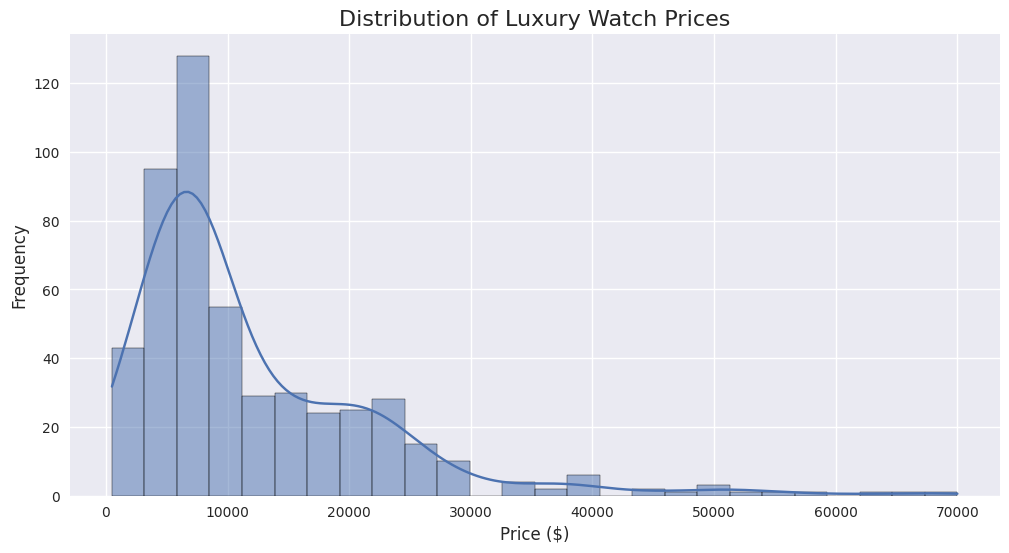

In [8]:
# Visualizing the price distribution
plt.figure(figsize=(12, 6))
sns.histplot(df['price'], kde=True)
plt.title('Distribution of Luxury Watch Prices', fontsize=16)
plt.xlabel('Price ($)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.show()

# 

### Analyzing Price vs Case Size
We'll investigate the relationship between a watch's case size and its price, considering different brands.

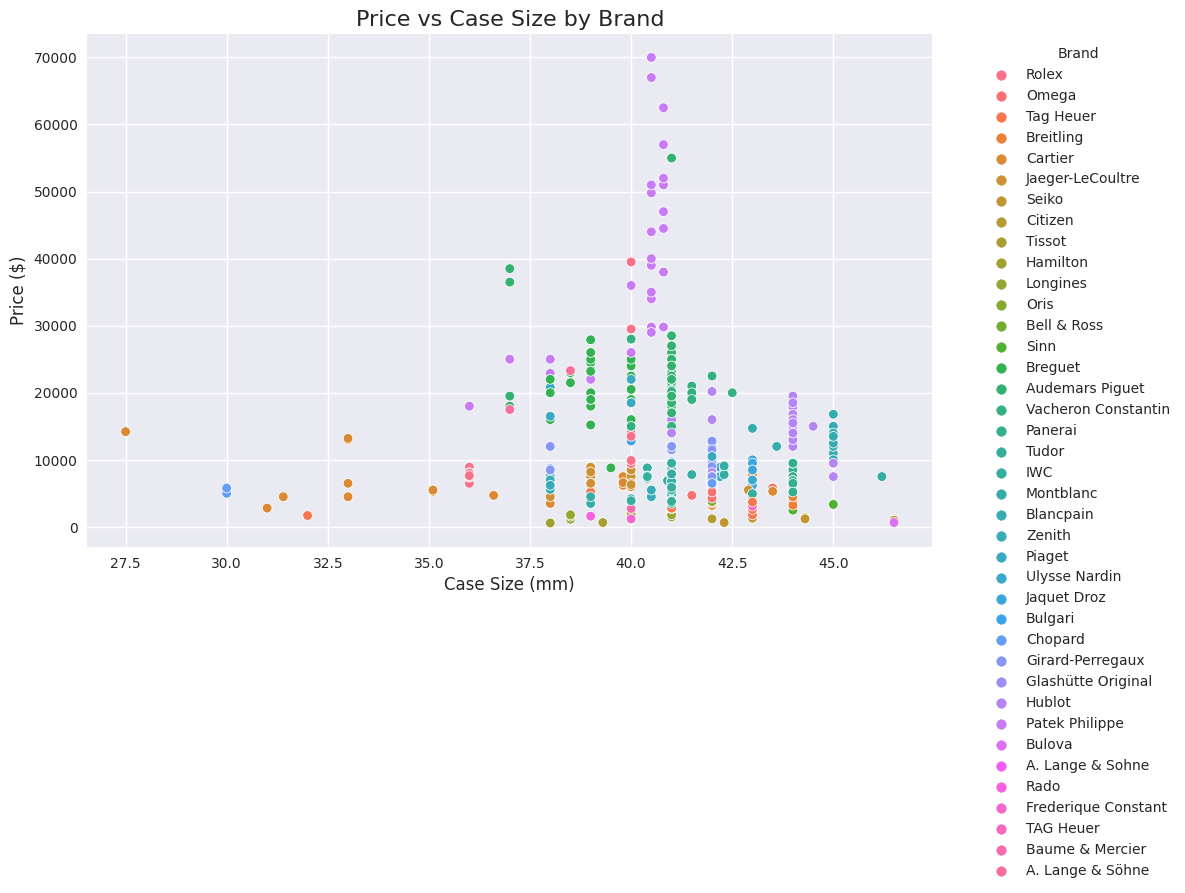

In [9]:
# Analyzing the relationship between case size and price
plt.figure(figsize=(12, 8))
sns.scatterplot(x='Case Diameter (mm)', y='price', hue='Brand', data=df)
plt.title('Price vs Case Size by Brand', fontsize=16)
plt.xlabel('Case Size (mm)', fontsize=12)
plt.ylabel('Price ($)', fontsize=12)
plt.legend(title='Brand', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

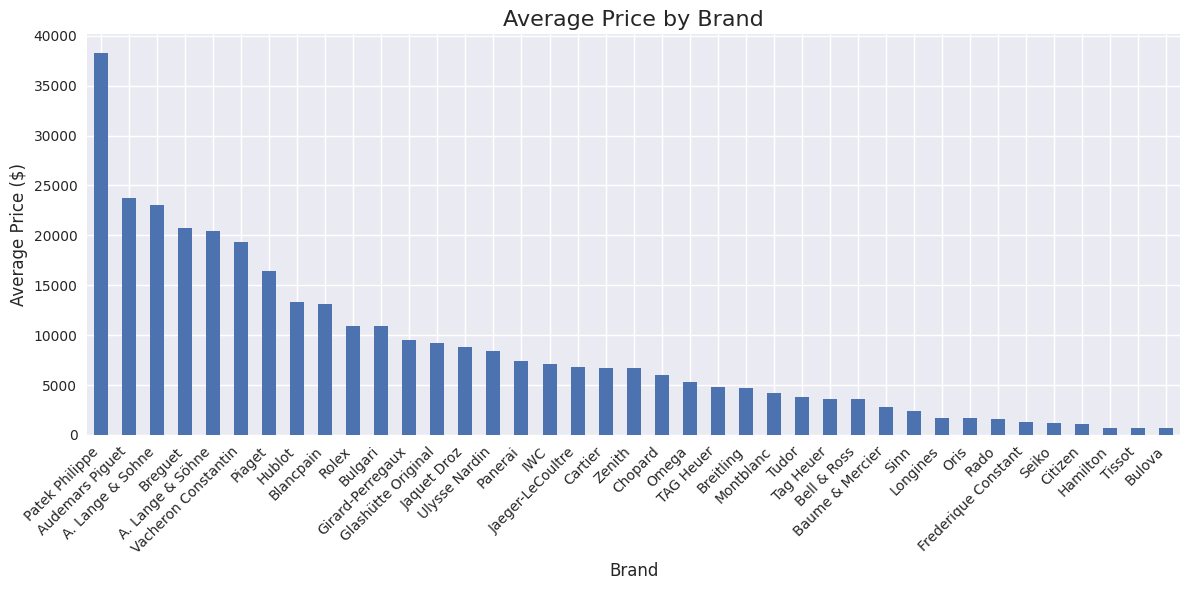

In [10]:
# Calculating average price by brand
brand_avg_price = df.groupby('Brand')['price'].mean().sort_values(ascending=False)
plt.figure(figsize=(12, 6))
brand_avg_price.plot(kind='bar')
plt.title('Average Price by Brand', fontsize=16)
plt.xlabel('Brand', fontsize=12)
plt.ylabel('Average Price ($)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

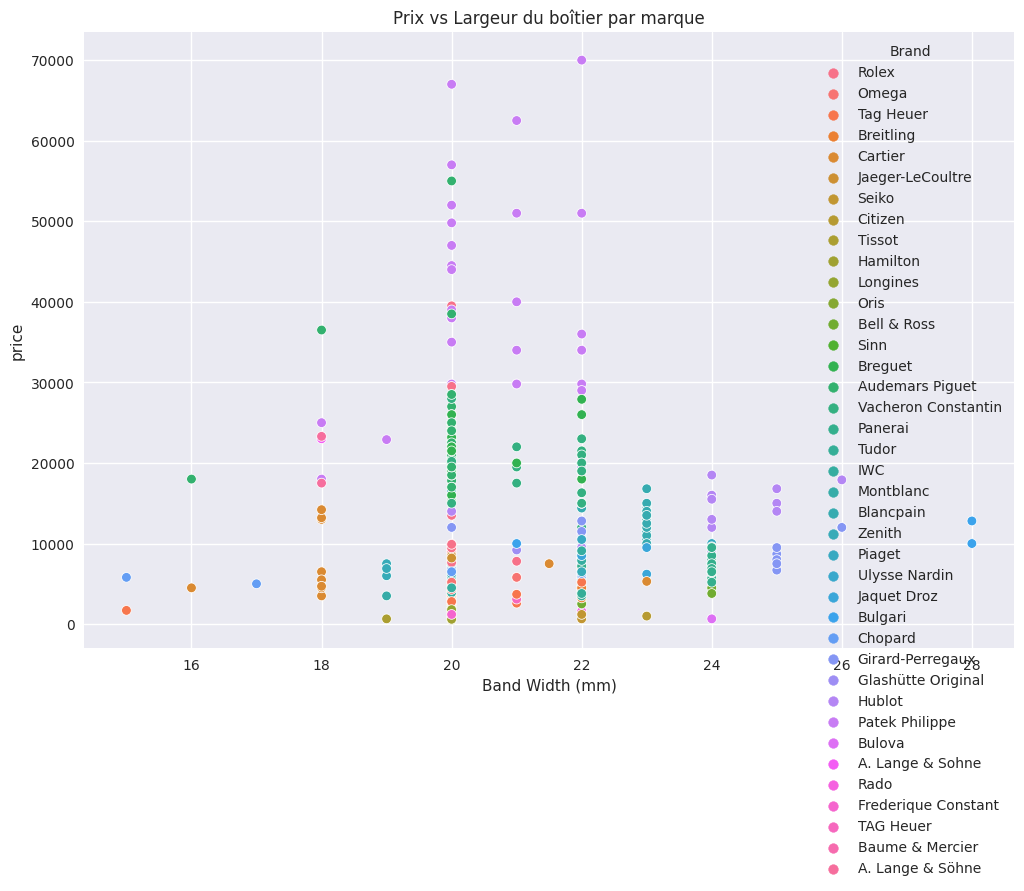

In [11]:
plt.figure(figsize=(12, 8))
sns.scatterplot(x='Band Width (mm)', y='price', hue='Brand', data=df)
plt.title('Prix vs Largeur du boîtier par marque')
plt.show()

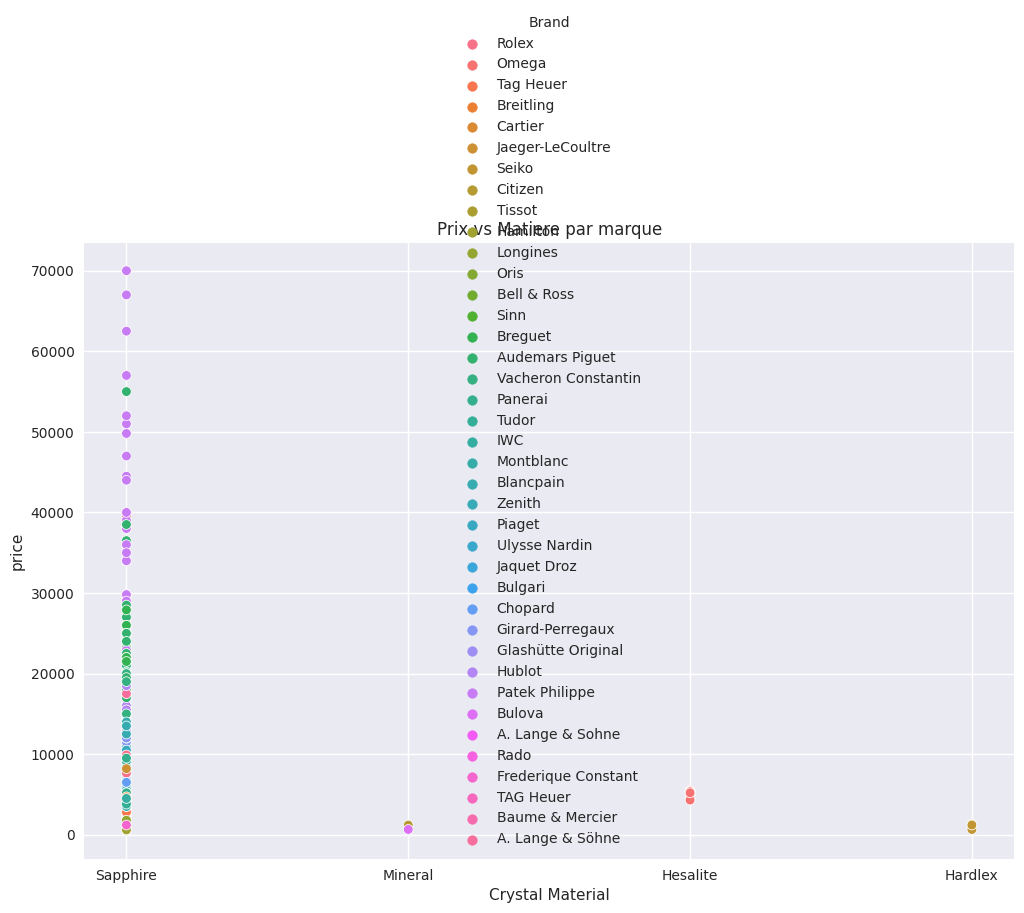

In [12]:
plt.figure(figsize=(12, 8))
sns.scatterplot(x='Crystal Material', y='price', hue='Brand', data=df)
plt.title('Prix vs Matiere par marque')
plt.show()

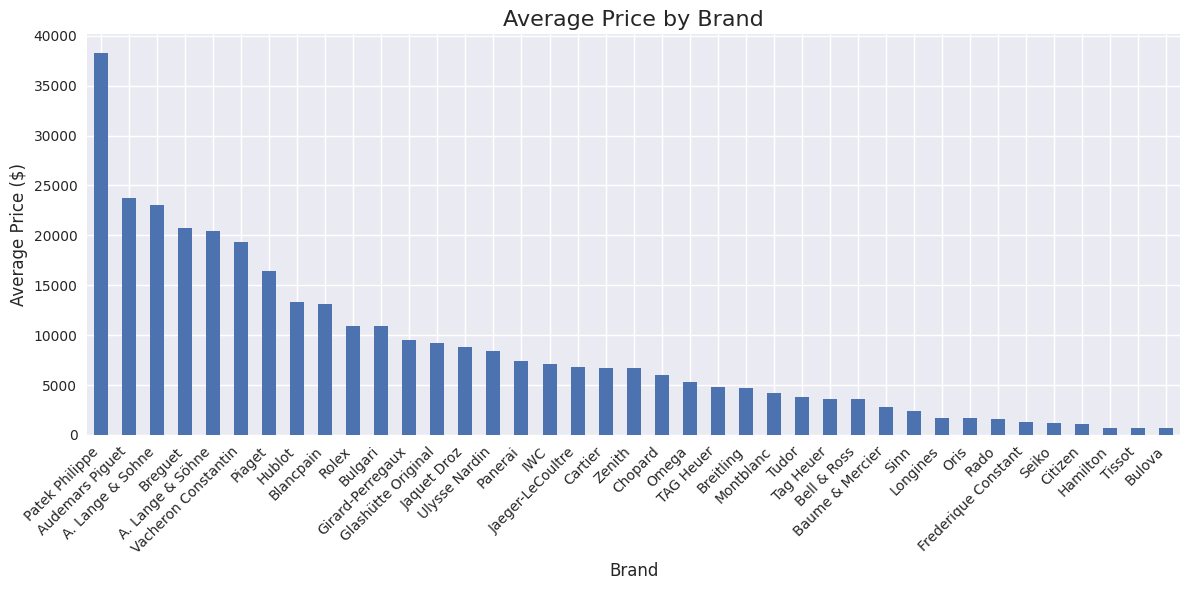

In [13]:
# Calculating average price by brand
brand_avg_price = df.groupby('Brand')['price'].mean().sort_values(ascending=False)
plt.figure(figsize=(12, 6))
brand_avg_price.plot(kind='bar')
plt.title('Average Price by Brand', fontsize=16)
plt.xlabel('Brand', fontsize=12)
plt.ylabel('Average Price ($)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Feature Analysis

### Numeric Correlations
We'll identify which numeric features have the strongest correlation with watch prices.

### Categorical Features
For categorical features, we'll use encoding techniques to prepare them for our model.

In [14]:
# Identifying numeric and categorical columns
numeric_columns = df.select_dtypes(include=[np.number]).columns
categorical_columns = df.select_dtypes(exclude=[np.number]).columns

print("Numeric columns:", numeric_columns)
print("Categorical columns:", categorical_columns)

Numeric columns: Index(['Case Diameter (mm)', 'Case Thickness (mm)', 'Band Width (mm)',
       'price'],
      dtype='object')
Categorical columns: Index(['Brand', 'Model', 'Case Material', 'Strap Material', 'Movement Type',
       'Water Resistance', 'Dial Color', 'Crystal Material', 'Complications',
       'Power Reserve', 'Price (USD)'],
      dtype='object')


In [15]:
# Calculating correlation for numeric columns
numeric_corr = df[numeric_columns].corr()['price'].sort_values(ascending=False)
print("Numeric correlations with price:")
print(numeric_corr)

Numeric correlations with price:
price                  1.000000
Case Diameter (mm)    -0.085783
Band Width (mm)       -0.088549
Case Thickness (mm)   -0.408458
Name: price, dtype: float64


In [16]:
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

categorical_corr = {}
for col in categorical_columns:
    categorical_corr[col] = cramers_v(df[col], df['price'])

categorical_corr = pd.Series(categorical_corr).sort_values(ascending=False)
print("\n Categorical correlations with price (V de Cramer):")
print(categorical_corr)


 Categorical correlations with price (V de Cramer):
Price (USD)         1.000000
Dial Color          0.506167
Case Material       0.430305
Movement Type       0.415873
Water Resistance    0.368052
Power Reserve       0.335264
Brand               0.327879
Strap Material      0.276703
Model               0.245354
Crystal Material    0.197778
Complications       0.000000
dtype: float64


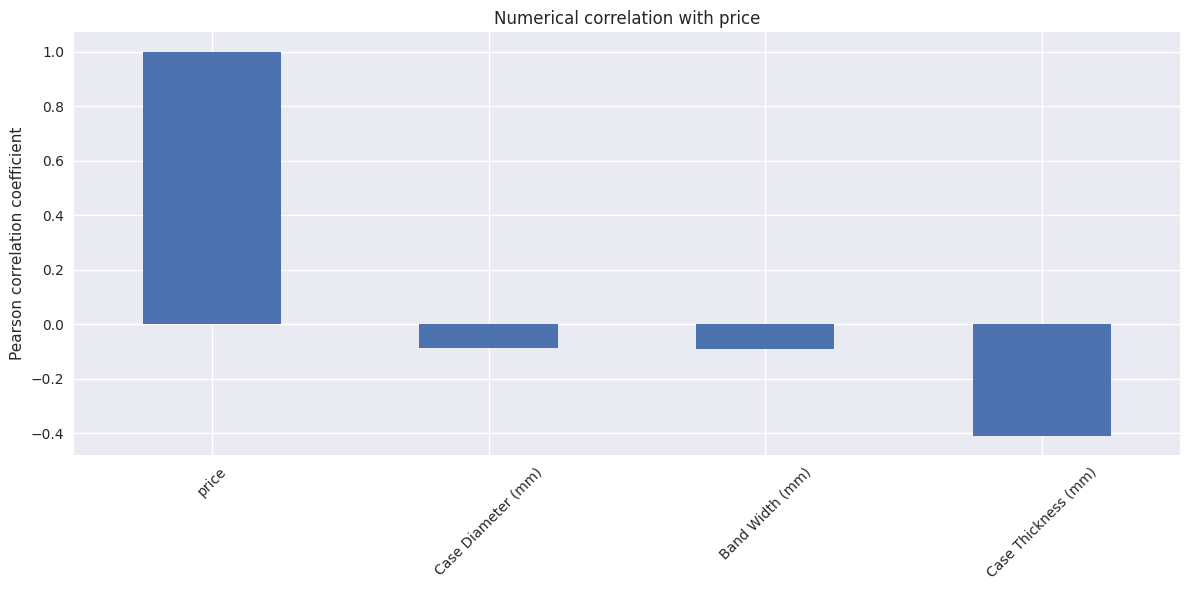

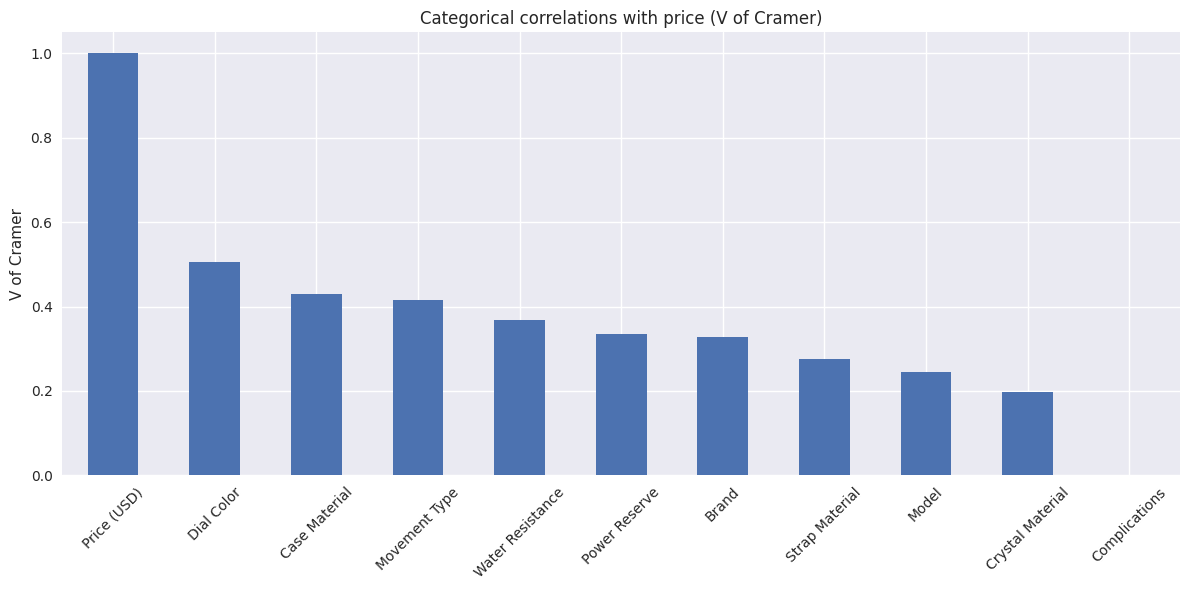

In [17]:
plt.figure(figsize=(12, 6))
numeric_corr.plot(kind='bar')
plt.title('Numerical correlation with price')
plt.ylabel('Pearson correlation coefficient')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
categorical_corr.plot(kind='bar')
plt.title('Categorical correlations with price (V of Cramer)')
plt.ylabel('V of Cramer')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

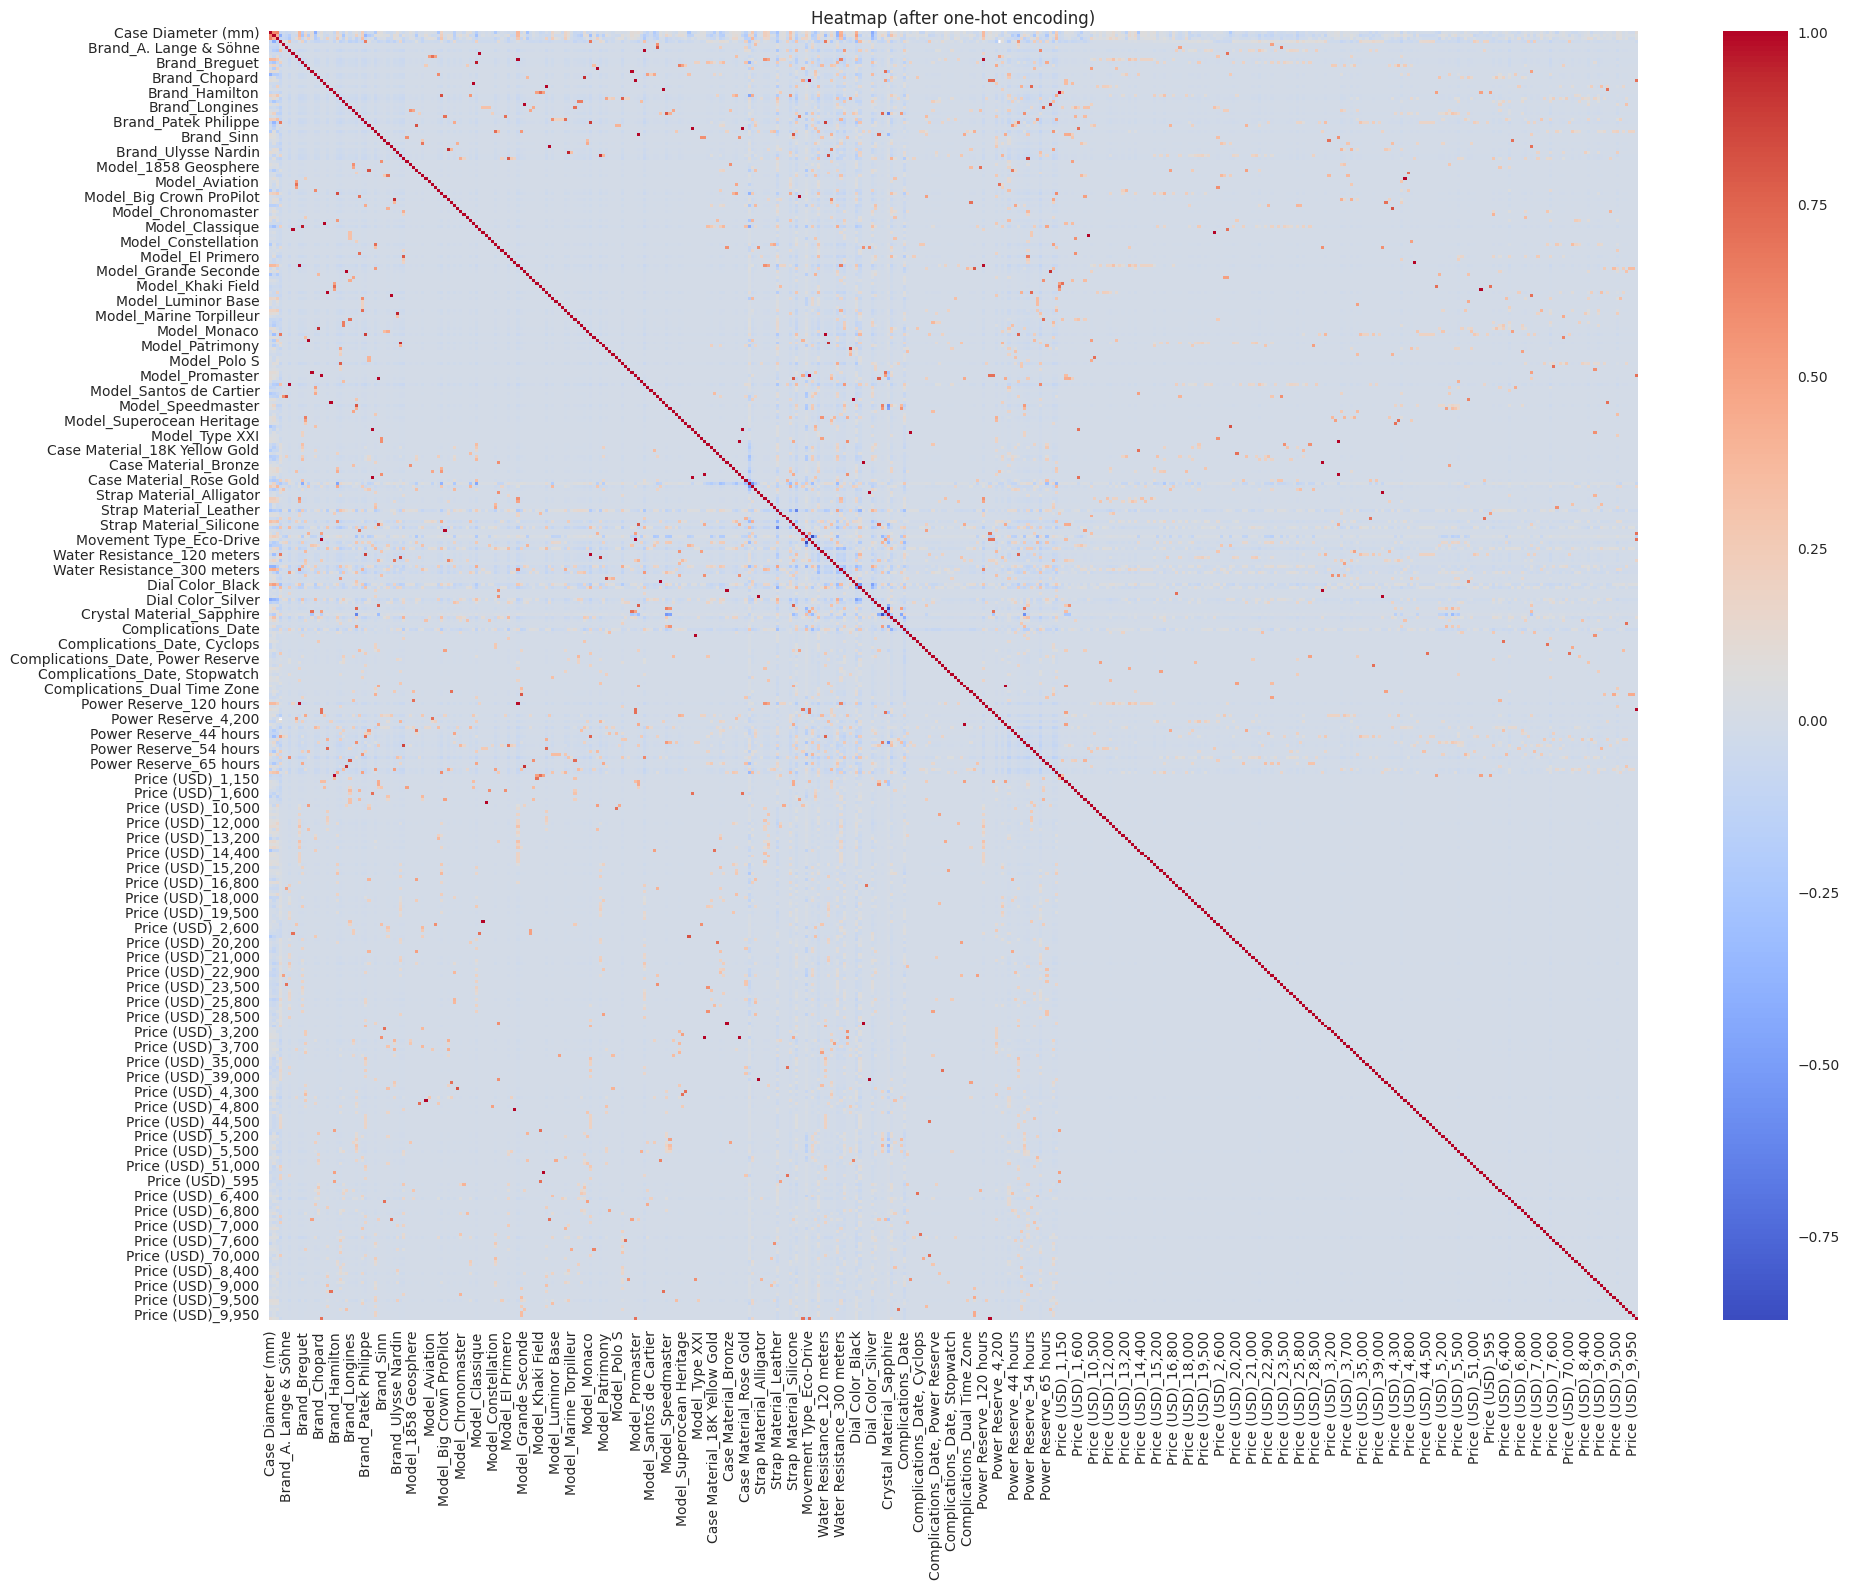

In [18]:
# One-hot encodage
df_encoded = pd.get_dummies(df, columns=categorical_columns)

# Heatmap creation
plt.figure(figsize=(20, 16))
sns.heatmap(df_encoded.corr(), annot=False, cmap='coolwarm')
plt.title('Heatmap (after one-hot encoding)')
plt.tight_layout()
plt.show()

## Model Building and Evaluation

### Random Forest Regression
We'll use a Random Forest Regressor to predict watch prices based on their features.

In [19]:
# Data preparing
X = df_encoded.drop('price', axis=1)
y = df_encoded['price']

In [20]:
print("Number of y values which are Nan :", y.isna().sum())

Number of y values which are Nan : 1


In [21]:
# Pu the average for missing y values

from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='mean')
y_imputed = imputer.fit_transform(y.values.reshape(-1, 1)).ravel()

print("Number of NaN y values after Imputer :", np.isnan(y_imputed).sum())

Number of NaN y values after Imputer : 0


In [22]:
# Splitting the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y_imputed, test_size=0.2, random_state=42)

# Scaling the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Creating and training the Random Forest model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train_scaled, y_train)

# Making predictions and evaluating the model
y_pred = model.predict(X_test_scaled)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MSE: {mse}")
print(f"R2 Score: {r2}")

MSE: 6662389.056058117
R2 Score: 0.8902554284513365


### Feature Importance
Finally, we'll analyze which features are most important in determining a watch's price according to our model.

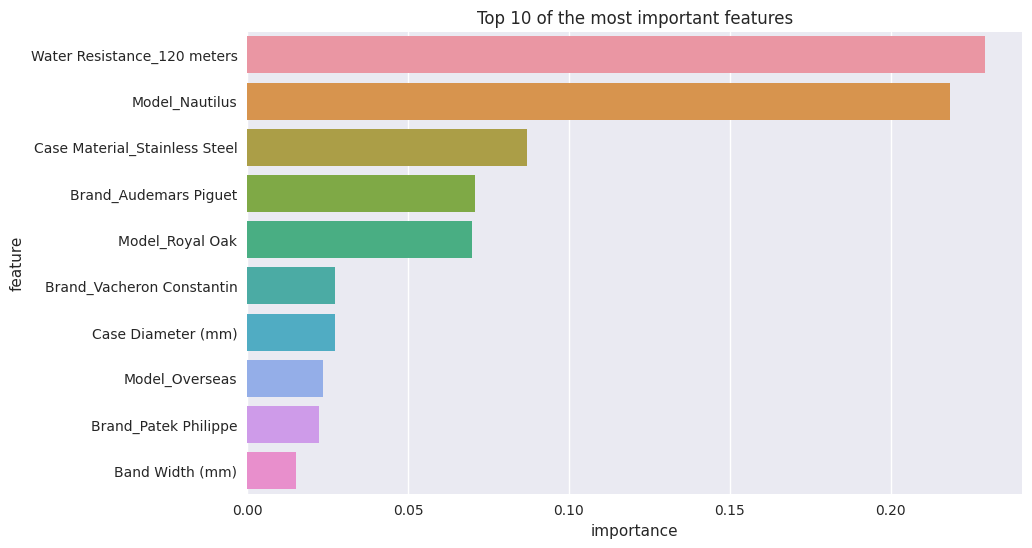

In [23]:
# Analyzing feature importance
feature_importance = pd.DataFrame({'feature': X.columns, 'importance': model.feature_importances_})
feature_importance = feature_importance.sort_values('importance', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=feature_importance)
plt.title('Top 10 of the most important features')
plt.show()

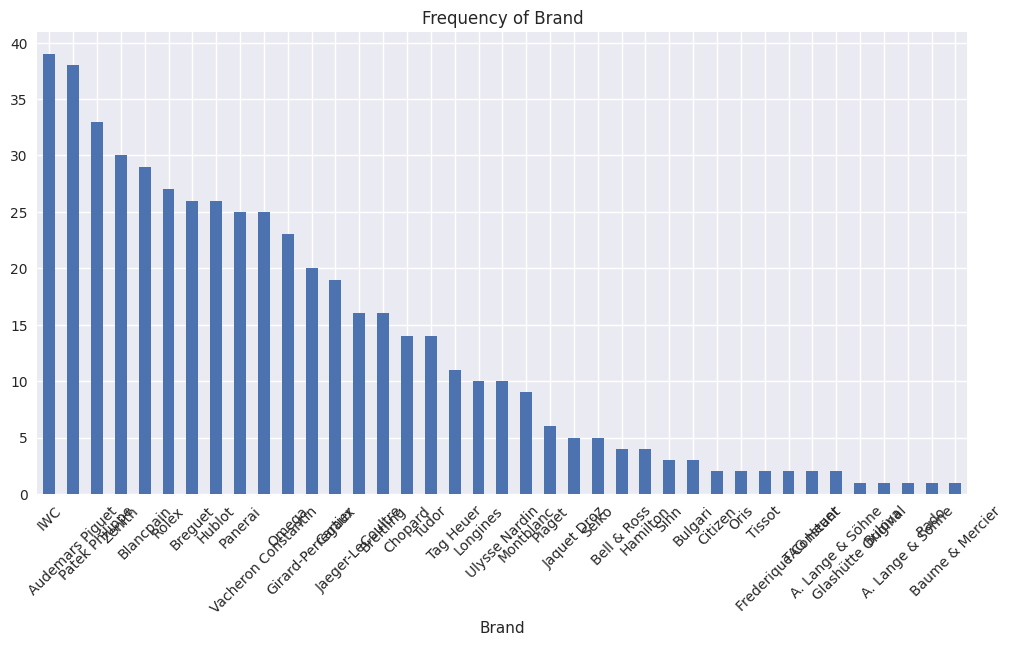

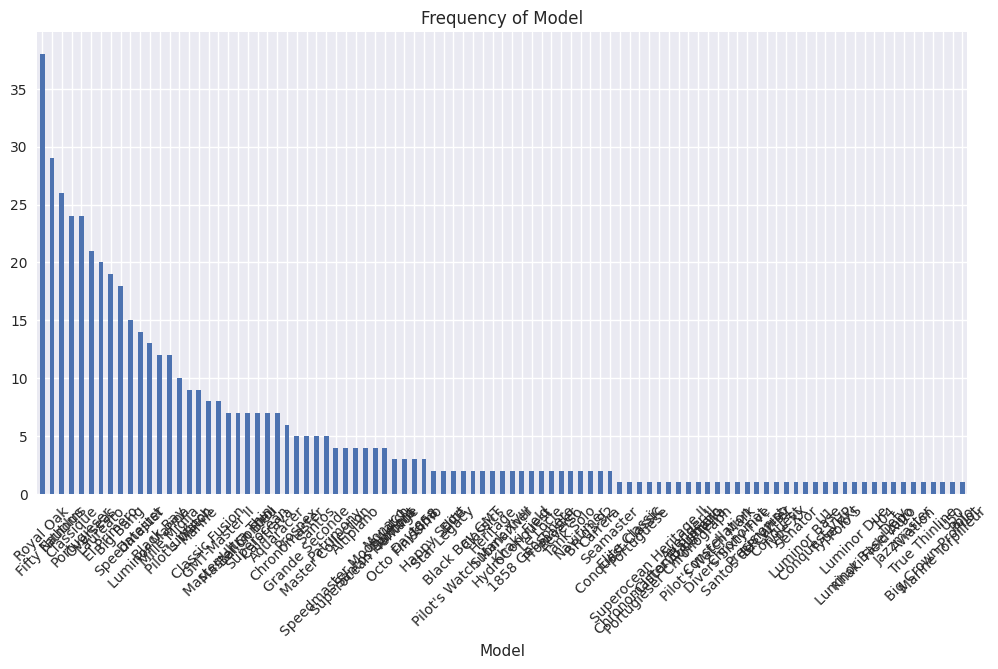

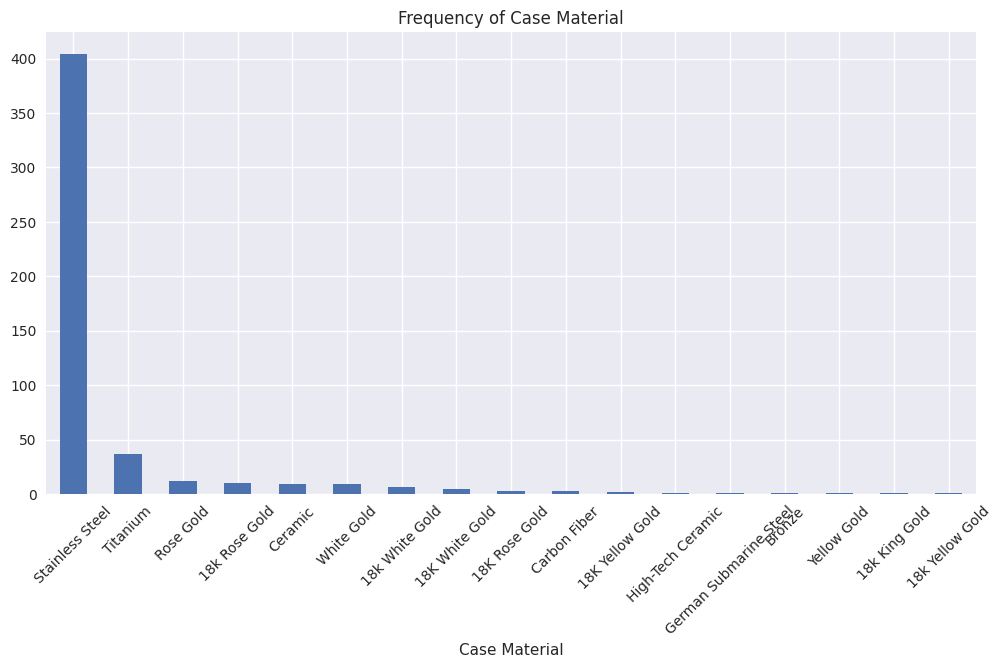

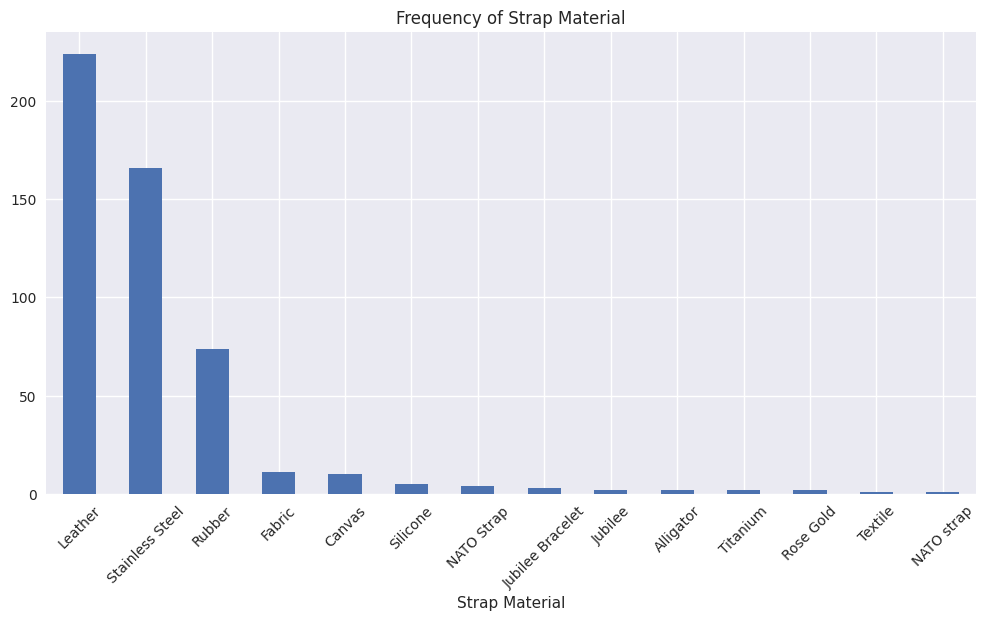

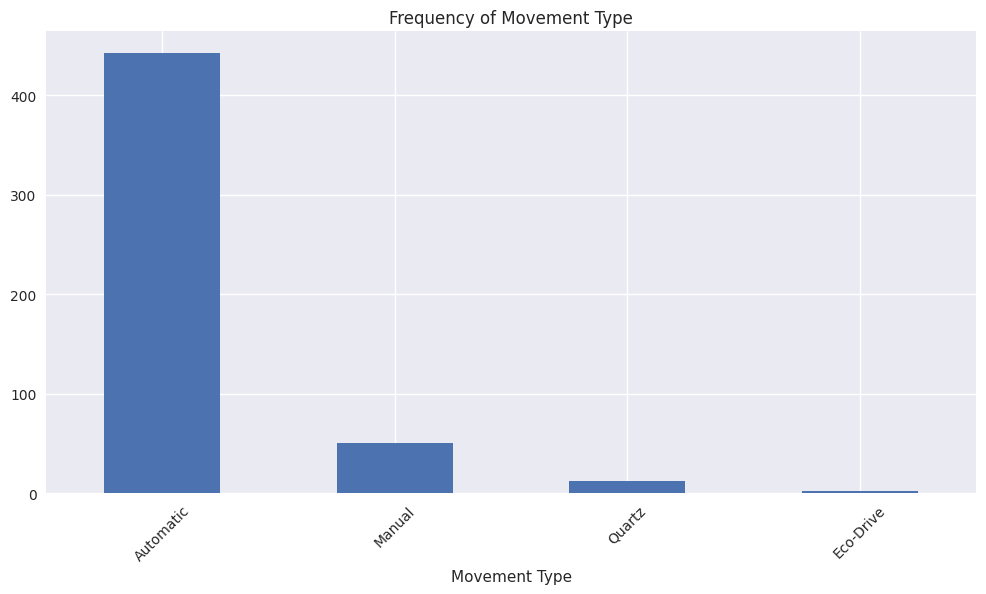

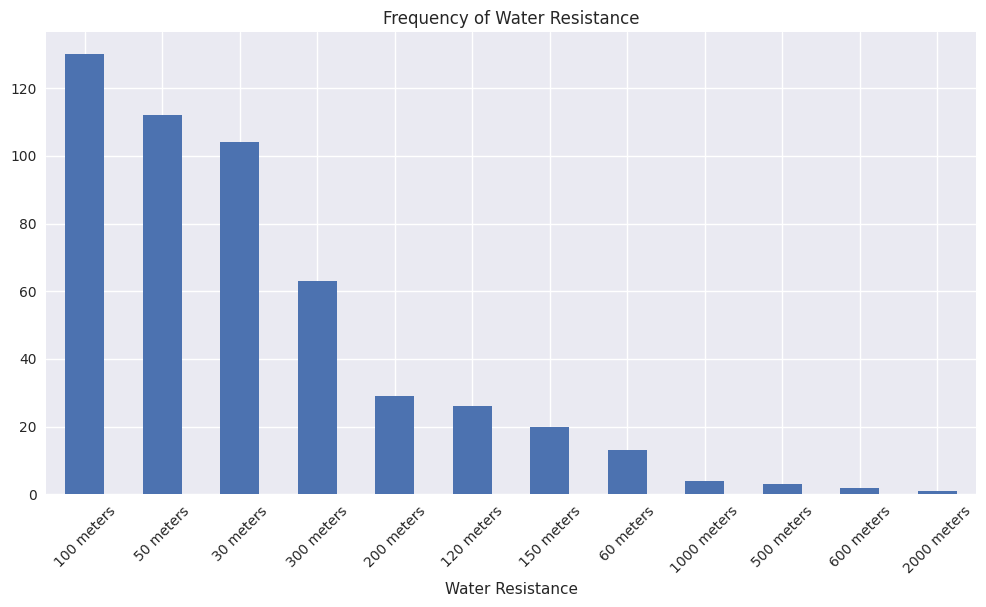

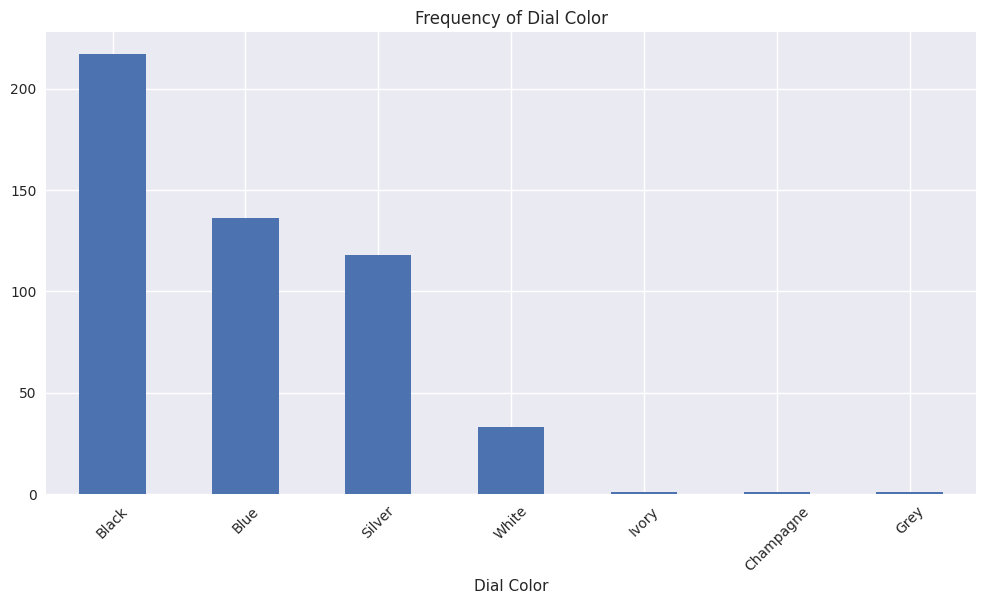

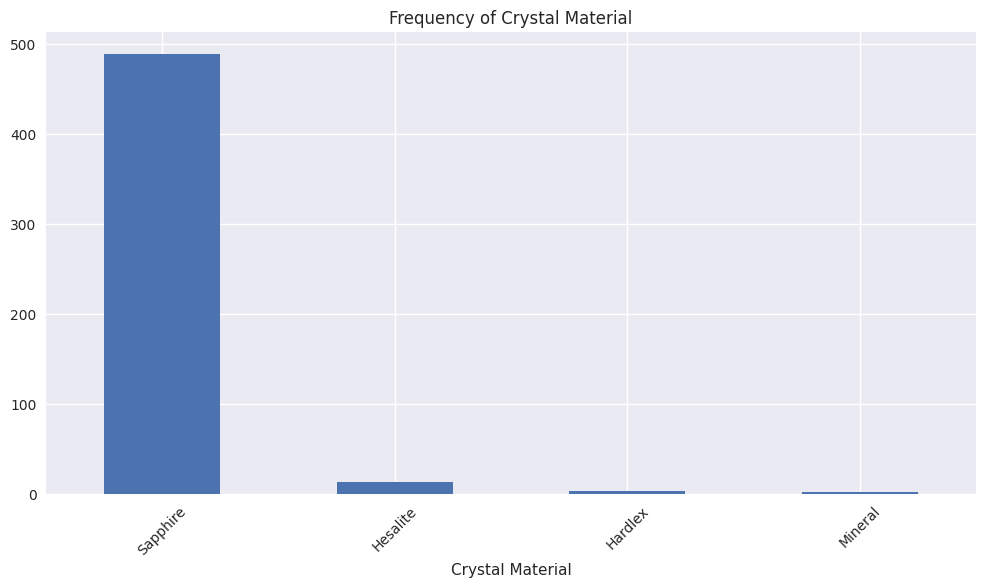

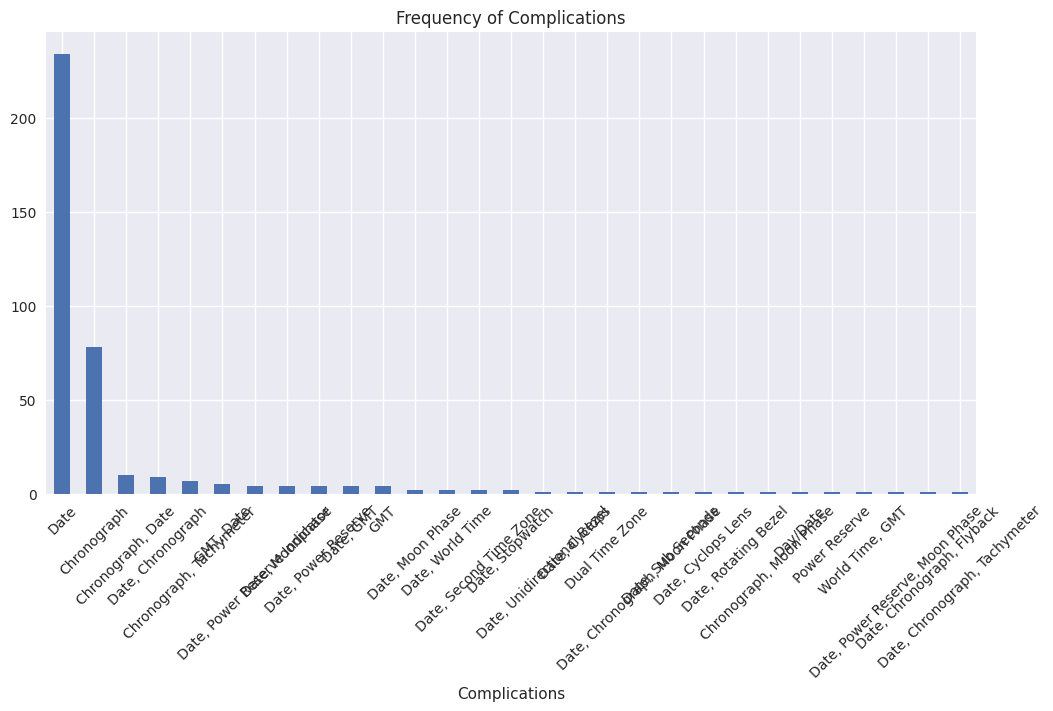

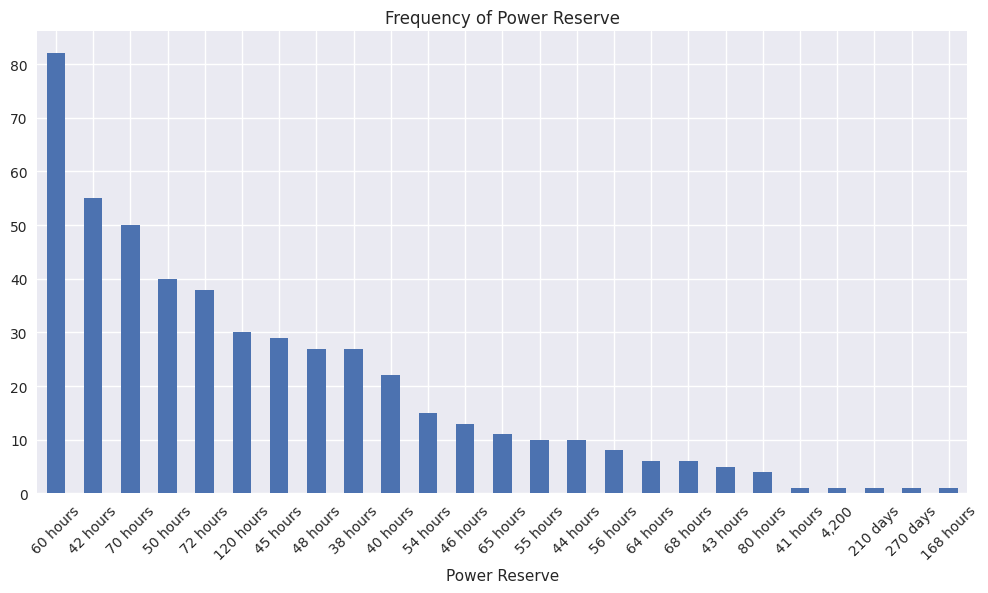

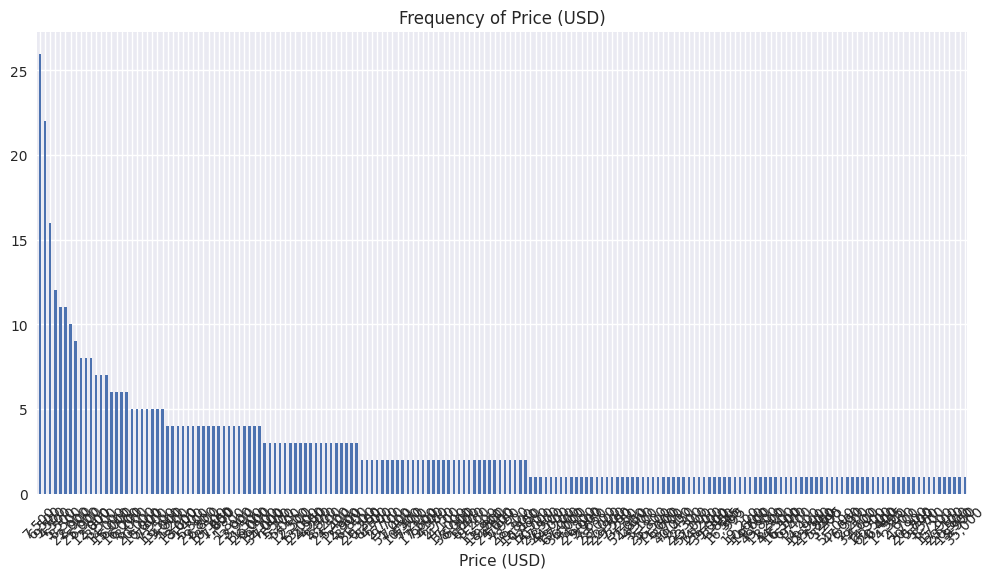

In [24]:
# Analyzing the frequency of the features
for col in categorical_columns:
    plt.figure(figsize=(12, 6))
    df[col].value_counts().plot(kind='bar')
    plt.title(f'Frequency of {col}')
    plt.xticks(rotation=45)
    plt.show()

In [25]:
# Most popula combinations
popular_combinations = df.groupby(['Brand', 'Case Material', 'Water Resistance'])['price'].count().sort_values(ascending=False).head(10)
print("Most popular combinations :")
print(popular_combinations)

Most popular combinations :
Brand                Case Material    Water Resistance
Audemars Piguet      Stainless Steel  50 meters           35
Patek Philippe       Stainless Steel  120 meters          26
IWC                  Stainless Steel  30 meters           26
Blancpain            Stainless Steel  300 meters          25
Rolex                Stainless Steel  100 meters          23
Zenith               Stainless Steel  100 meters          22
Girard-Perregaux     Stainless Steel  100 meters          20
Omega                Stainless Steel  50 meters           19
Vacheron Constantin  Stainless Steel  150 meters          19
Tudor                Stainless Steel  200 meters          14
Name: price, dtype: int64


In [26]:
import plotly.express as px
import plotly.graph_objects as go

# Average price per brand
fig1 = px.bar(df.groupby('Brand')['price'].mean().sort_values(ascending=False), 
              title='Average price per brand')

# Distribution of price per material
fig2 = px.box(df, x='Case Material', y='price', title='Distribution of price per material')

# Relationship between the size of box and price
fig3 = px.scatter(df, x='Case Diameter (mm)', y='price', color='Brand', 
                  title='Relationship between size of the box and price')

# Depicting figures
fig1.show()
fig2.show()
fig3.show()

## Conclusion
### Price Distribution
The prices of luxury watches in the dataset exhibit a strong asymmetry, with a long tail towards higher prices. The majority of watches fall within a lower price range, but there are extremely expensive models that skew the average upwards.

### Relationship Between Case Size and Price
There appears to be a slight positive trend between all the features and price; however, this relationship is not very strong. Other factors likely have a greater influence on pricing.

### Average Price by Brand
There is significant variation in average prices among brands. Brands such as Patek Philippe and A. Lange & Söhne stand out with notably higher average prices compared to others.

### Model Performance
The Random Forest model achieved an R-squared value of approximately 0.89, indicating good predictive performance. However, the Mean Squared Error is relatively high, suggesting that the model may have significant errors on certain predictions.

### Important Features
The most important features for predicting price according to the model include:
- **Model**
- **Water resistance**

### Implications for Inventory and Pricing Strategy
- High-end brands such as Patek Philippe and A. Lange & Söhne should be managed with special attention due to their high value.
- Watches made from precious materials like rose gold deserve special consideration in inventory management.
- Case size and number of complications can be used to strategically adjust pricing and manage inventory effectively.